**Table of contents**<a id='toc0_'></a>    
- [Photoswiching fingerprints of 4 fluorophores](#toc1_)    
  - [Reading data](#toc1_1_)    
    - [PFA data](#toc1_1_1_)    
      - [2 fluorophores](#toc1_1_1_1_)    
      - [4 fluorophores](#toc1_1_1_2_)    
    - [Lifetime data](#toc1_1_2_)    
      - [3 nm *d*STORM](#toc1_1_2_1_)    
      - [18 nm *d*STORM](#toc1_1_2_2_)    
      - [3 nm *d*STORM detailed and with bleaching](#toc1_1_2_3_)    
      - [3 nm Trolox](#toc1_1_2_4_)    
      - [18 nm Trolox](#toc1_1_2_5_)    
  - [Figure](#toc1_2_)    
    - [Preparation](#toc1_2_1_)    
    - [Figure](#toc1_2_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Photoswiching fingerprints of 4 fluorophores](#toc0_)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import fluopy.emissions as em
import fluopy.figure as fi
import fluopy.fluorophores as fl
import fluopy.routines as rt
import fluopy.simulation as si
import fluopy.transitions as tr

%load_ext autoreload
%autoreload 2

reading_from = r"D:\python_output\Chapter_I\0_4_multi_f_PFA"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
fluopy.blinking version: 0.1.0
fluopy.distributions version: 0.1.0
fluopy.emissions version: 0.1.0
fluopy.figure version: 0.1.0


### <a id='toc1_1_1_'></a>[PFA data](#toc0_)

### <a id='toc1_1_2_'></a>[Lifetime data](#toc0_)

#### <a id='toc1_1_2_1_'></a>[3 nm *d*STORM](#toc0_)

In [ ]:
rng = np.random.default_rng(42)
target_path = reading_from + r"\4F_lifetime\3nm_dstorm"
event_time_series = pd.read_parquet(target_path + r"\event_time_series.parquet")
event_time_series = pd.Series(
    event_time_series.values.flatten(), index=event_time_series.index
)
lifetimes_all_3nm_dstorm = np.load(target_path + r"\tau.npy")

emis_3nm_dstorm = em.Emissions(seed=rng, **rt.PARAMS_EMIS)
emis_3nm_dstorm.event_time_series = event_time_series
rt.emission_post_processing(emis=emis_3nm_dstorm, seed=rng)

print(f"Fluorescence lifetime: {np.mean(lifetimes_all_3nm_dstorm)}")

Fluorescence lifetime: 1.6606369343454845e-09


#### <a id='toc1_1_2_2_'></a>[18 nm *d*STORM](#toc0_)

In [ ]:
rng = np.random.default_rng(42)
target_path = reading_from + r"\4F_lifetime\18nm_dstorm"
event_time_series = pd.read_parquet(target_path + r"\event_time_series.parquet")
event_time_series = pd.Series(
    event_time_series.values.flatten(), index=event_time_series.index
)
lifetimes_all_18nm_dstorm = np.load(target_path + r"\tau.npy")

emis_18nm_dstorm = em.Emissions(seed=rng, **rt.PARAMS_EMIS)
emis_18nm_dstorm.event_time_series = event_time_series
rt.emission_post_processing(emis=emis_18nm_dstorm, seed=rng)

print(f"Fluorescence lifetime: {np.mean(lifetimes_all_18nm_dstorm)}")

Fluorescence lifetime: 1.6780934343244296e-09


#### <a id='toc1_1_2_3_'></a>[3 nm *d*STORM detailed and with bleaching](#toc0_)

In [ ]:
rng = np.random.default_rng(42)
target_path = reading_from + r"\4F_lifetime\3nm_dstorm_bl_details"
event_time_series = pd.read_parquet(target_path + r"\event_time_series.parquet")
event_time_series = pd.Series(
    event_time_series.values.flatten(), index=event_time_series.index
)
lifetimes_all_3nm_dstorm_bl = np.load(target_path + r"\tau.npy")

# should be the same transition set as the one used for the simulation
fluorophores = fl.construct_fluorophores(
    name="cy5_dna", count=4, distance=3, shape="square"
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
transitions = fluorophore_system.load_transitions(
    bleaching=True,
    summarize=True,
    energy_transfer=True,
    **rt.PARAMS_DSTORM,
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()

transition_series = np.load(target_path + r"\transition_series.npy")
state_series = np.load(target_path + r"\state_series.npy")
time_series = np.load(target_path + r"\time_series.npy")

simulation_3nm_dstorm_bl = si.Simulation(transition_set)
simulation_3nm_dstorm_bl.time_series = time_series
simulation_3nm_dstorm_bl.transition_series = transition_series
simulation_3nm_dstorm_bl.state_series = state_series

emis_3nm_dstorm_bl = em.Emissions(seed=rng, **rt.PARAMS_EMIS)
emis_3nm_dstorm_bl.event_time_series = event_time_series

times_of_bleaching = []
for state_series in simulation_3nm_dstorm_bl.state_series:
    if state_series[-1] == 5:
        time_of_bleaching = simulation_3nm_dstorm_bl.time_series[
            np.where(state_series == 5)[0][0]
        ]
        times_of_bleaching.append(time_of_bleaching)
times_of_bleaching = np.sort(np.array(times_of_bleaching))

ser = emis_3nm_dstorm_bl.event_time_series
mean_lifetimes = []
start = 0
start_index = 0
for time in times_of_bleaching:
    sum_events = ser[(ser.index < time) & (ser.index > start)].sum()
    mean_lifetime = lifetimes_all_3nm_dstorm_bl[
        start_index : start_index + sum_events
    ].mean()
    mean_lifetimes.append(mean_lifetime)
    start = time
    start_index += sum_events
# the post processing after lifetimes such that they have better statistics
rt.emission_post_processing(emis=emis_3nm_dstorm_bl, seed=rng)

print(f"Fluorescence lifetime: {np.mean(lifetimes_all_3nm_dstorm_bl)}")

Fluorescence lifetime: 1.8661301936227283e-09


WARNING for line:     mean_lifetime = lifetimes_all_3nm_dstorm_bl[start_index:start_index + sum_events].mean()
 Mean of empty slice. 
WARNING for line:             ret = ret.dtype.type(ret / rcount)
 invalid value encountered in scalar divide 


#### <a id='toc1_1_2_4_'></a>[3 nm Trolox](#toc0_)

In [ ]:
rng = np.random.default_rng(42)
target_path = reading_from + r"\4F_lifetime\3nm_trolox"
event_time_series = pd.read_parquet(target_path + r"\event_time_series.parquet")
event_time_series = pd.Series(
    event_time_series.values.flatten(), index=event_time_series.index
)
lifetimes_all_3nm_trolox = np.load(target_path + r"\tau.npy")

emis_3nm_trolox = em.Emissions(seed=rng, **rt.PARAMS_EMIS)
emis_3nm_trolox.event_time_series = event_time_series
rt.emission_post_processing(emis=emis_3nm_trolox, seed=rng)

print(f"Fluorescence lifetime: {np.mean(lifetimes_all_3nm_trolox)}")

Fluorescence lifetime: 1.5308822680014117e-09


#### <a id='toc1_1_2_5_'></a>[18 nm Trolox](#toc0_)

In [ ]:
rng = np.random.default_rng(42)
target_path = reading_from + r"\4F_lifetime\18nm_trolox"
event_time_series = pd.read_parquet(target_path + r"\event_time_series.parquet")
event_time_series = pd.Series(
    event_time_series.values.flatten(), index=event_time_series.index
)
lifetimes_all_18nm_trolox = np.load(target_path + r"\tau.npy")

emis_18nm_trolox = em.Emissions(seed=rng, **rt.PARAMS_EMIS)
emis_18nm_trolox.event_time_series = event_time_series
rt.emission_post_processing(emis=emis_18nm_trolox, seed=rng)

print(f"Fluorescence lifetime: {np.mean(lifetimes_all_18nm_trolox)}")

Fluorescence lifetime: 1.6853969143045096e-09


## <a id='toc1_2_'></a>[Figure](#toc0_)

### <a id='toc1_2_2_'></a>[Figure](#toc0_)

ValueError: not enough values to unpack (expected 2, got 1)

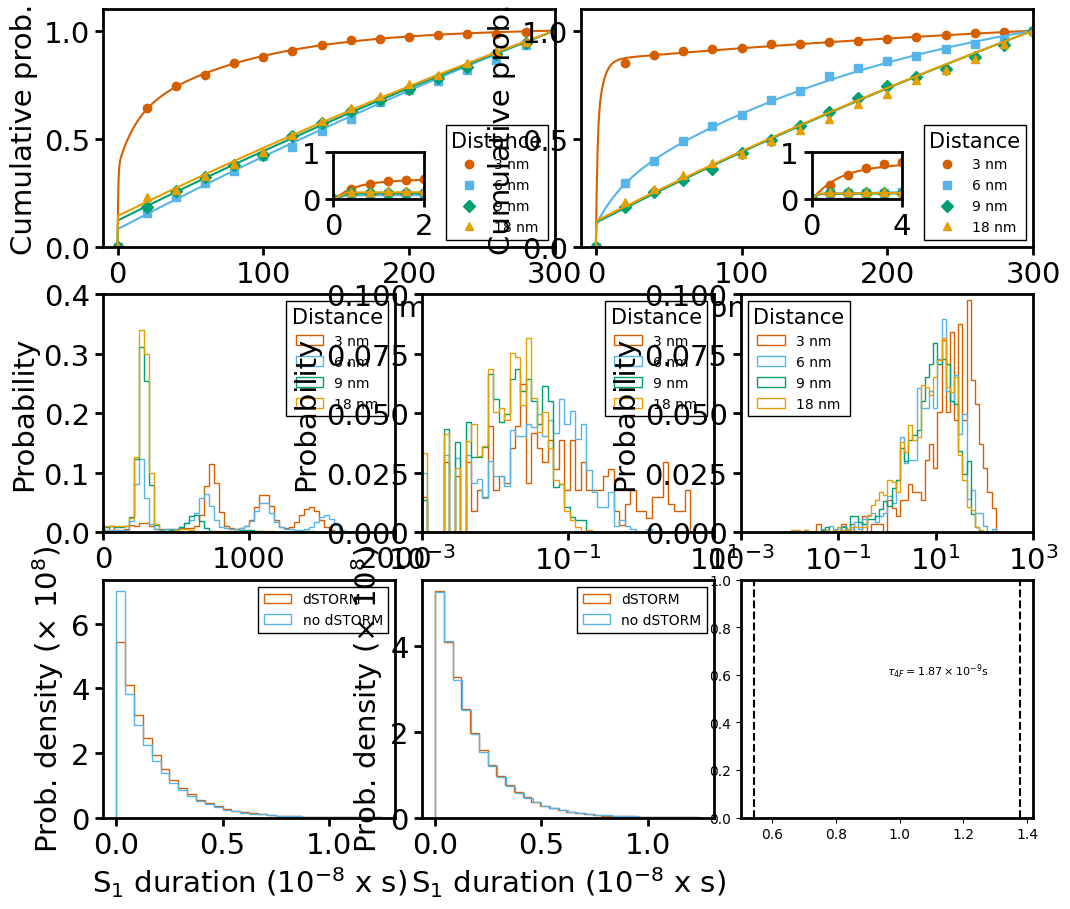

In [ ]:
red = "#D55E00"
sky_blue = "#56B4E9"
green = "#009E73"
orange = "#E69F00"
colors = [red, sky_blue, green, orange]

gs = plt.GridSpec(3, 4)
fig = plt.figure(figsize=(15, 12))
ax6 = fig.add_subplot(gs[2, 0:2])
fi.universal_figure(
    type_="hist",
    data=lifetimes_all_3nm_dstorm,
    axes=ax6,
    bins=30,
    histtype="step",
    color=red,
    label="dSTORM",
    density=True,
)
fi.universal_figure(
    type_="hist",
    data=lifetimes_all_3nm_trolox,
    axes=ax6,
    bins=30,
    histtype="step",
    color=sky_blue,
    label="no dSTORM",
    density=True,
    legend=True,
    tick_style_x="sci",
    tick_style_y="sci",
    xlabel="S" + r"$_{" + "1" + r"}$" + " duration (s)",
    ylabel="Prob. density",
    legendargs=dict(
        framealpha=1,
        edgecolor="black",
        fancybox=False,
    ),
)
ax7 = fig.add_subplot(gs[2, 2:4])
fi.universal_figure(
    type_="hist",
    data=lifetimes_all_18nm_dstorm,
    axes=ax7,
    bins=30,
    histtype="step",
    color=red,
    label="dSTORM",
    density=True,
)
fi.universal_figure(
    type_="hist",
    data=lifetimes_all_18nm_trolox,
    axes=ax7,
    bins=30,
    histtype="step",
    color=sky_blue,
    label="no dSTORM",
    density=True,
    legend=True,
    tick_style_x="sci",
    tick_style_y="sci",
    xlabel="S" + r"$_{" + "1" + r"}$" + " duration (s)",
    ylabel="Prob. density",
    legendargs=dict(
        framealpha=1,
        edgecolor="black",
        fancybox=False,
    ),
)
ax8 = fig.add_subplot(gs[2, 4:])
for j, time_bleaching in enumerate(times_of_bleaching):
    label = None
    if j == 3:
        label = r"$t_{BLE}$"
    ax8.axvline(
        x=time_bleaching,
        ymin=0,
        ymax=1,
        color="black",
        linestyle="--",
        label=label,
        zorder=10,
    )
    base, exp = f"{mean_lifetimes[j]:.2e}".split("e")
    formatted = f"$ {base} \\times 10^{{{int(exp)}}} $"
    ax8.text(
        s=rf"$\tau_{{{4 - j}F}} =$" + formatted + "s",
        x=0.5,
        y=0.6 - 0.1 * j,
        color="black",
        fontsize=8,
        transform=ax8.transAxes,
    )
emis_3nm_dstorm_bl.plot_time_series(
    axes=ax8,
    color=red,
    legend=True,
    zorder=1,
    legendargs=dict(
        framealpha=1,
        edgecolor="black",
        fancybox=False,
    ),
    xlim=[0, 1.25],
    ylim=[0, 300],
)
axes = fig.get_axes()
for axis, letter in zip(axes, ["A", "B", "C", "D", "E", "F", "G", "H"]):
    offset = -0.05
    axis.text(
        offset,
        1.1,
        letter,
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )
fig.tight_layout()
fig.savefig(
    reading_from + r"\multi_f_PFA.png", dpi=300, bbox_inches="tight", pad_inches=0.1
)